In [2]:
## Task 1
##Imports
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [13]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
## Data loading
df = pd.read_csv("customer_support_text_classification.csv")

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [15]:
## Dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (1500, 6)


In [16]:
## Data types
print(df.dtypes)

ticket_id             str
channel               str
customer_message      str
sentiment_label       str
word_count          int64
urgent_flag         int64
dtype: object


In [17]:
## Target labels
print(df["sentiment_label"].unique())

<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str


In [18]:
## sample records
print(df["customer_message"].head())

0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: str


In [19]:
## Average text length
df["text_length"] = df["customer_message"].apply(len)

print("Average Text Length:",
      df["text_length"].mean())

Average Text Length: 72.75666666666666


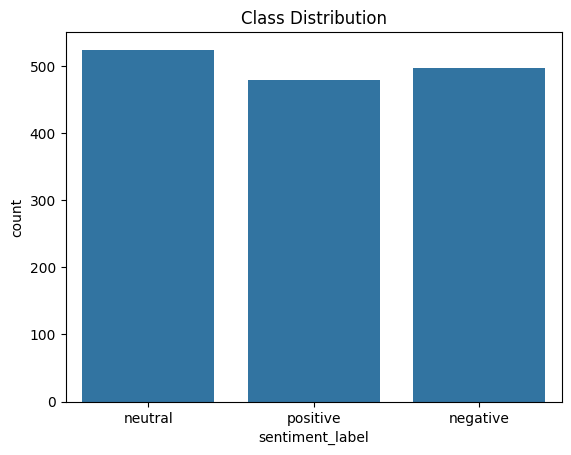

In [20]:
## class distribution
sns.countplot(
    x="sentiment_label",
    data=df
)

plt.title("Class Distribution")

plt.show()

In [21]:
## Task 2
## clean text function
stop_words = set(stopwords.words('english'))

def clean_text(text):

    # lowercase
    text = text.lower()

    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # tokenize
    tokens = word_tokenize(text)

    # remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

In [23]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [24]:
## Cleaning
df["clean_text"] = df["customer_message"].apply(clean_text)

df[["customer_message",
    "clean_text"]].head()

,customer_message,clean_text
0,I need information about the payment process. ...,need information payment process ticket number...
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I ...,refund process fast convenient appreciate quic...
3,My refund is still pending and this experience...,refund still pending experience frustrating ti...
4,Please tell me how to update my account details.,please tell update account details


In [25]:
## Task 3
## TF IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_text"])

y = df["sentiment_label"]

# Why Text Must Be Converted into Vectors

Machine learning models cannot understand raw text directly.

Text must be converted into numerical vectors so that models can identify:
- word frequency
- patterns
- semantic importance

TF-IDF helps measure how important a word is within a document compared to the entire dataset.

In [26]:
## Task 4
## Train Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [27]:
## Logistic Regression moedl
model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [28]:
## Predictions
y_pred = model.predict(X_test)

In [29]:
## Evaluation
print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



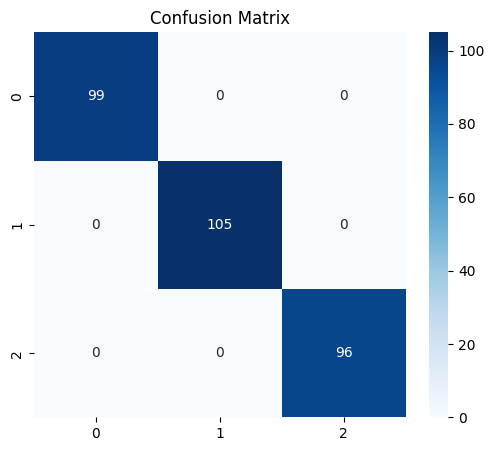

In [30]:
## Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")

plt.show()

In [31]:
## save Evaluation results
results_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        output_dict=True
    )
).transpose()

import os

os.makedirs("results", exist_ok=True)

results_df.to_csv(
    "results/model_evaluation.csv"
)

In [32]:
## Task 5
## Tokenizer
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df["clean_text"])

In [33]:
## convert text to sequences
sequences = tokenizer.texts_to_sequences(
    df["clean_text"]
)

In [34]:
## Padding
X_seq = pad_sequences(
    sequences,
    maxlen=50,
    padding='post'
)

In [35]:
## Encode labels
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

In [36]:
## Train test split
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [37]:
## Building LSTM Model
lstm_model = Sequential([

    Embedding(
        input_dim=5000,
        output_dim=64,
        input_length=50
    ),

    LSTM(64),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')
])

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [38]:
## Compling
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
## Training
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=5,
    batch_size=32
)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.3300 - loss: 1.0998 - val_accuracy: 0.3467 - val_loss: 1.0984
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3500 - loss: 1.0988 - val_accuracy: 0.3467 - val_loss: 1.0982
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3500 - loss: 1.0990 - val_accuracy: 0.3467 - val_loss: 1.0990
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3500 - loss: 1.0988 - val_accuracy: 0.3467 - val_loss: 1.0987
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3500 - loss: 1.0985 - val_accuracy: 0.3467 - val_loss: 1.0984


In [40]:
## Evaluate
loss, accuracy = lstm_model.evaluate(
    X_test_seq,
    y_test_seq
)

print("Test Accuracy:", accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3467 - loss: 1.0984
Test Accuracy: 0.3466666638851166


# Sequence Model Architecture

## Input Sequence
Text messages are converted into sequences of token IDs.

## Embedding Layer
Transforms tokens into dense numerical vectors that capture semantic meaning.

## LSTM Layer
Processes sequences while remembering important previous information.

## Output Layer
Predicts the sentiment class:
- positive
- neutral
- negative

## Loss Function
Sparse Categorical Crossentropy

## Evaluation Metric
Accuracy

## Task 6
# Attention and Transformer Reflection

## Why RNNs Struggle with Long-Term Dependencies

Traditional RNNs process text sequentially and often forget older information when sequences become long.

This is known as the vanishing gradient problem.

---

## How LSTMs Help with Memory

LSTMs use memory cells and gating mechanisms to retain important information for longer periods.

This improves sequence learning performance.

---

## What Attention Solves

Attention allows the model to focus on the most important words in a sequence instead of relying only on the previous hidden state.

This improves performance in translation and sequence-to-sequence tasks.

---

## Why Transformers Are Important

Transformers process sequences in parallel using self-attention mechanisms.

Advantages:
- Faster training
- Better handling of long text
- Improved contextual understanding

Modern Generative AI systems such as ChatGPT use transformer architectures.

In [41]:
sample_preds = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

sample_preds.to_csv(
    "results/sample_predictions.txt",
    sep='\t',
    index=False
)